<a href="https://colab.research.google.com/github/tomarjyoti16/assignment-05-bitsom_ba_2511563_part-3-nlp-sequence-modeling/blob/main/NLP_and_Sequence_Modeling_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Dataset Understanding

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("sample_data/customer_support_text_classification.csv")

# Number of records
print("\nNumber of records:", len(df))

# Target labels/classes
print("\nTarget labels/classes:")
print(df['sentiment_label'].unique())

# Sample text records
print("\nSample text records:")
print(df['customer_message'].head(5))

# Average text length
# Using word count from customer_message
avg_length = df['customer_message'].apply(lambda x: len(str(x).split())).mean()
print("\nAverage text length:", round(avg_length, 2), "words")

# Class distribution
print("\nClass distribution:")
print(df['sentiment_label'].value_counts())




Number of records: 1500

Target labels/classes:
['neutral' 'positive' 'negative']

Sample text records:
0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object

Average text length: 12.72 words

Class distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


Task 2: Text Preprocessing

In [2]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

#Select text column
text_column = 'customer_message'

#Stopwords
stop_words = set(stopwords.words('english'))

#Text preprocessing function

def preprocess_text(text):
    #Lowercase
    text = text.lower()

    #Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    #Tokenization
    tokens = word_tokenize(text)

    #Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    #Join tokens back into sentence
    return ' '.join(tokens)

#Apply preprocessing
df['cleaned_text'] = df[text_column].apply(preprocess_text)

#Display sample cleaned text
print("\nSample cleaned text:")
print(df[['customer_message','cleaned_text']].head(5))

#Convert text into sequences
max_words = 5000
max_len = 100

#Tokenier
tokenizer = Tokenizer(num_words = max_words)
tokenizer.fit_on_texts(df['cleaned_text'])

#Convert text onto sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

#Padding and truncating sequences
padded_sequences = pad_sequences(sequences, maxlen = max_len, padding='post', truncating='post')

#Display shape of padded sequences
print("\nShape of padded sequences:", padded_sequences.shape)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Sample cleaned text:
                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  

Shape of padded sequences: (1500, 100)


Task 3: Text Vectorization

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Use cleaned text column
texts = df['cleaned_text']

# Apply TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into numerical vectors
X = tfidf.fit_transform(texts)

# Display shape of TF-IDF matrix
print("Shape of TF-IDF matrix:", X.shape)

# Display some feature names
print("\nSample features:")
print(tfidf.get_feature_names_out()[:20])

# Display vector for first text record
print("\nTF-IDF vector of first record:")
print(X[0].toarray())


Shape of TF-IDF matrix: (1500, 146)

Sample features:
['account' 'activate' 'ago' 'analytics' 'app' 'appreciate' 'arrived'
 'assigned' 'available' 'bad' 'billing' 'call' 'cancel' 'care' 'charged'
 'checking' 'clear' 'communication' 'completed' 'confirm']

TF-IDF vector of first record:
[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.44084662 0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.35345568 0.         0.
  0.         0.20627565 0.         0.         0.     

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Input and target columns
X_text = df['cleaned_text']
y = df['sentiment_label']

#Conver text into TF-IDF vectors
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(X_text)

#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Create Logistic Regression model
model = LogisticRegression(max_iter=1000)

#Train the model
model.fit(X_train, y_train)

#Make predictions
y_pred = model.predict(X_test)

#Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

#Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:
[[109   0   0]
 [  0 104   0]
 [  0   0  87]]


Task 5: Sequence Model using LSTM

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Input and target columns
texts = df['cleaned_text']
labels = df['sentiment_label']

# Encode target labels
encoder = LabelEncoder()
y = encoder.fit_transform(labels)

# Convert labels to categorical
y = to_categorical(y)

# Tokenization
max_words = 5000
max_length = 20

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)

# Convert text into sequences
sequences = tokenizer.texts_to_sequences(texts)

# Padding sequences
X = pad_sequences(
    sequences,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build LSTM model
model = Sequential()

# Embedding layer
model.add(Embedding(input_dim=max_words,
                    output_dim=128,
                    input_length=max_length))

# LSTM layer
model.add(LSTM(64))

# Output layer
model.add(Dense(3, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
model.summary()

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.5667 - loss: 0.8894 - val_accuracy: 1.0000 - val_loss: 0.0946
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 0.0127 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 1.0000 - val_loss: 9.7149e-04
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 1.0000 - loss: 8.1801e-04 - val_accuracy: 1.0000 - val_loss: 6.8344e-04
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 1.0000 - loss: 5.9480e-04 - val_accuracy: 1.0000 - val_loss: 5.1391e-04
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 5.1391e-04 
Test Accuracy: 1.0
Test Loss: 0.0005139060085639358


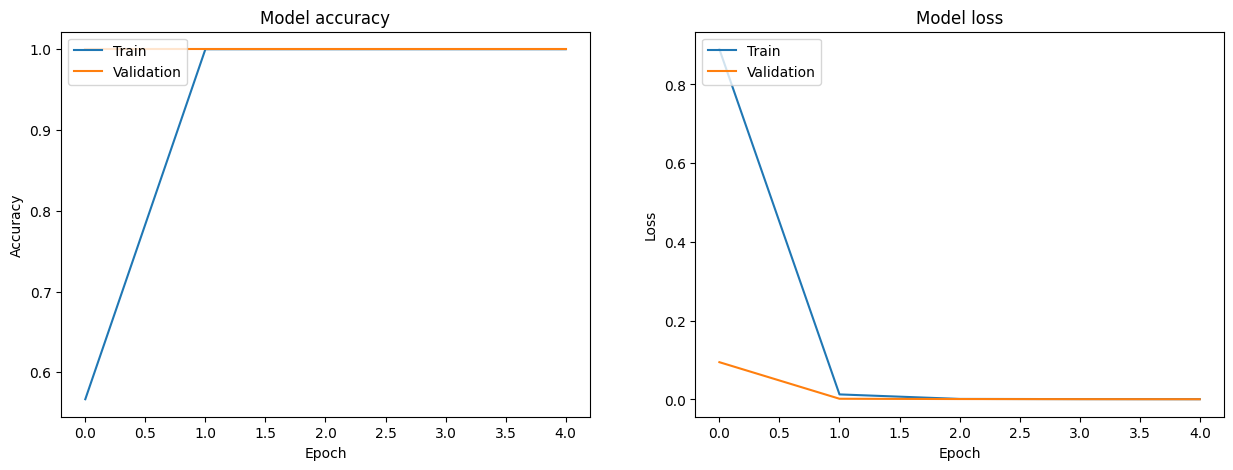

In [6]:
import matplotlib.pyplot as plt

# Plot training history
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot training & validation accuracy values
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='upper left')

    # Plot training & validation loss values
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper left')
    plt.show()

plot_history(history)

## Task 7: Model Comparison (LSTM vs. Logistic Regression)

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Re-create Logistic Regression model's data and predictions
# (Assuming `df` and `cleaned_text` are available from previous cells)

X_text_lr = df['cleaned_text']
y_labels_lr = df['sentiment_label']

tfidf_vectorizer_lr = TfidfVectorizer(max_features=5000)
X_lr = tfidf_vectorizer_lr.fit_transform(X_text_lr)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_lr, y_labels_lr, test_size=0.2, random_state=42)

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_lr, y_train_lr)
y_pred_lr = model_lr.predict(X_test_lr)

# --- Logistic Regression Model Performance ---
print("\n--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test_lr, y_pred_lr):.4f}")
print("Classification Report:")
print(classification_report(y_test_lr, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test_lr, y_pred_lr))

# --- LSTM Model Performance ---
print("\n--- LSTM Model Performance ---")

# Get test accuracy from history (last validation accuracy)
lstm_accuracy = history.history['val_accuracy'][-1]
print(f"Test Accuracy: {lstm_accuracy:.4f}")

# Make predictions with the LSTM model on the test set
y_pred_lstm_prob = model.predict(X_test)
y_pred_lstm_labels = np.argmax(y_pred_lstm_prob, axis=1)

# Decode true labels for comparison
y_test_lstm_decoded = np.argmax(y_test, axis=1)

# Get class names from the LabelEncoder used in the LSTM setup
class_names = encoder.classes_

# Map numerical predictions back to original labels
y_pred_lstm_original_labels = [class_names[pred] for pred in y_pred_lstm_labels]
y_test_lstm_original_labels = [class_names[true] for true in y_test_lstm_decoded]

print("Classification Report:")
print(classification_report(y_test_lstm_original_labels, y_pred_lstm_original_labels, target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_test_lstm_original_labels, y_pred_lstm_original_labels))


--- Logistic Regression Model Performance ---
Accuracy: 1.0000
Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
 [[109   0   0]
 [  0 104   0]
 [  0   0  87]]

--- LSTM Model Performance ---
Test Accuracy: 1.0000
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00 

## Task 8: Sample Predictions

In [9]:
# Define sample customer messages
sample_messages = [
    "I am very happy with the service!",
    "This is absolutely terrible, I want a refund.",
    "The agent was polite and helpful.",
    "I need to know my account balance.",
    "My internet is down and no one is helping me."
]

# Preprocess the sample messages
preprocessed_sample_messages = [preprocess_text(msg) for msg in sample_messages]
print("\n--- Preprocessed Sample Messages ---")
for msg in preprocessed_sample_messages:
    print(msg)

# Convert preprocessed messages to sequences using the fitted tokenizer
sample_sequences = tokenizer.texts_to_sequences(preprocessed_sample_messages)

# Pad the sequences to the same length as the training data
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=max_length, padding='post', truncating='post')

# Make predictions with the LSTM model
sample_predictions_prob = model.predict(sample_padded_sequences)

# Convert probabilities to predicted labels (indices)
sample_predicted_labels_indices = np.argmax(sample_predictions_prob, axis=1)

# Decode the predicted labels back to original sentiment labels
sample_predicted_labels = encoder.inverse_transform(sample_predicted_labels_indices)

print("\n--- Sample Predictions ---")
for i, message in enumerate(sample_messages):
    print(f"Original: {message}")
    print(f"Predicted Sentiment: {sample_predicted_labels[i]} (Confidence: {np.max(sample_predictions_prob[i]):.2f})")
    print("\n")


--- Preprocessed Sample Messages ---
happy service
absolutely terrible want refund
agent polite helpful
need know account balance
internet one helping
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step

--- Sample Predictions ---
Original: I am very happy with the service!
Predicted Sentiment: negative (Confidence: 1.00)


Original: This is absolutely terrible, I want a refund.
Predicted Sentiment: negative (Confidence: 1.00)


Original: The agent was polite and helpful.
Predicted Sentiment: negative (Confidence: 1.00)


Original: I need to know my account balance.
Predicted Sentiment: neutral (Confidence: 1.00)


Original: My internet is down and no one is helping me.
Predicted Sentiment: negative (Confidence: 1.00)




Architecture Explanation
1. Input Sequence

* The customer messages are first converted into sequences of integers using a tokenizer. Each word gets a unique numerical index

2. Embedding Layer

* The embedding layer converts each word index into dense numerical vectors. It helps the model learn semantic meaning and relationships between words.

3. Recurrent Layer (LSTM)

* The LSTM layer processes the text sequence step-by-step and remembers important contextual information from previous words. This helps in understanding sentence meaning and sentiment.

4. Output Layer

* The output layer predicts probabilities for the three sentiment classes:

	Positive
	Negative
	Neutral

* Softmax selects the class with highest probability.

5. Loss Function

* This loss function is used for multi-class classification problems and measures prediction error.

6. Evaluation Metric

* Accuracy measures how many predictions are correctly classified out of total predictions.

Task 6: Attention and Transformer Reflection
1. Why RNNs Struggle with Long-Term Dependencies

* RNNs process text one word at a time and pass information from previous steps through hidden states. When sequences become very long, earlier information gradually becomes weak or lost. This problem is called the vanishing gradient problem. Because of this, RNNs struggle to remember important words or context from earlier parts of a sentence.

* Example:

- In a long sentence, the model may forget important information mentioned at the beginning before reaching the end.

2. How LSTMs Help with Memory

* LSTMs (Long Short-Term Memory networks) improve RNNs by introducing a memory cell and gates:

	- Forget Gate → Removes unnecessary information
	- Input Gate → Stores important new information
	- Output Gate → Decides what information to pass forward

* These gates help the model remember useful information for longer periods and reduce the vanishing gradient problem.

* As a result, LSTMs perform better on tasks like sentiment analysis, language modeling, and text generation.

3. What Attention Solves in Sequence-to-Sequence Tasks

* In traditional sequence models, the encoder tries to compress the entire sentence into a single fixed-size vector. This becomes difficult for long sentences.

* The attention mechanism solves this by allowing the model to focus on the most relevant words while generating each output word.

* Instead of using only one fixed context vector, attention dynamically checks important parts of the input sequence.

* Benefits of attention:

	Better handling of long sentences
	Improved translation quality
	Better context understanding
	More accurate predictions

4. Why Transformers Are Important in Modern NLP and Generative AI

* Transformers are advanced deep learning architectures based mainly on the attention mechanism. Unlike RNNs, transformers process all words in parallel instead of one-by-one.

* Advantages of transformers:

	- Faster training
	- Better handling of long-range dependencies
	- Improved accuracy
	- Scalable to very large datasets

* Transformers are the foundation of modern NLP and Generative AI systems such as:

  - OpenAI models like GPT
  - Google BERT
  - Translation systems
  - Chatbots
  - Text summarization tools
  - AI assistants

* They are widely used because they understand context more effectively and generate human-like text with high accuracy.